# **Climate Forecasting Using Machine Learning: 02 Feature Ablation**

---

### **Notebook Summary**

This notebook evaluates how different groups of climate data sources influence 1-month-ahead temperature anomaly forecasting. All retained models are kept in the run, and every model is given access to the selected data sources.

### **Ablation settings**
- AR only
- AR + teleconnections
- AR + SST
- AR + teleconnections + SST
- AR + ENSO
- AR + teleconnections + ENSO
- AR + SST + ENSO
- AR + teleconnections + SST + ENSO
- SST runs use the local noaa_raw_data/sst_cache folder
- retained models: Ridge, Huber, XGBoost, LSTM, PatchTST, iTransformer, NHiTS
- random seed = 42

### **What this notebook should answer**
1. Does adding teleconnections help beyond autoregressive features?
2. Does adding SST help beyond autoregressive features?
3. Does adding ENSO help beyond autoregressive features?
4. Which data-source setting should be carried into the later notebooks?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    path = Path(path)
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except (OSError, ValueError):
        return path.as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.pipeline import run_backtest


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("Repository setup complete.")
print("Import path: src")

Repository setup complete.
Import path: src


### **Figure export helper**

Plots saved by this notebook are written to the shared case-analysis image folder so the final Markdown report can reference stable figure files.

In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Configurations**

This cell defines the shared modeling settings used by every ablation run. All retained models are kept. Classical and tree models read the full feature table directly, iTransformer reads the feature table as tokens, and the sequence models use AR lags plus an exogenous branch for non-lag climate data sources.

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"

TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")

RANDOM_SEED = 42

for path in [TAVG_FILE, SST_DIR]:
    print(f"{project_relative(path)} -> {Path(path).exists()}")

if not Path(SST_DIR).exists():
    raise FileNotFoundError(
        "SST cache is required for notebook 02. Expected: "
        f"{project_relative(SST_DIR)}"
    )


RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


BASE_CFG = dict(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,

    # Keep decision layers OFF for clean feature comparisons
    use_qmap=False,
    use_month_alpha_choice=False,

    # Compact research model set
    use_ridge=True,
    use_huber=True,
    use_xgb=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,

    # Keep this notebook focused on 1-month forecasting
    H=1,

    plot_test=False,
    verbose=True,
)

print("Retained research model set:", RESEARCH_MODEL_SET)
portable_config(BASE_CFG)

noaa_raw_data/nclimgrid_tavg.nc -> True
noaa_raw_data/sst_cache -> True
Retained research model set: ['Ridge', 'Huber', 'XGBoost', 'LSTM', 'PatchTST', 'iTransformer', 'NHiTS']


{'tavg_file': 'noaa_raw_data/nclimgrid_tavg.nc',
 'sst_dir': 'noaa_raw_data/sst_cache',
 'enso_csv': 'noaa_raw_data/nina34.anom.csv',
 'random_seed': 42,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'use_ridge': True,
 'use_huber': True,
 'use_xgb': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'H': 1,
 'plot_test': False,
 'verbose': True}

### **Model input scope**

This table documents how each retained model receives the selected data sources. Sequence models keep their AR lag sequence input, but now also receive non-lag climate features through an exogenous branch.

In [4]:
MODEL_INPUT_SCOPE = pd.DataFrame([
    {"Model": "Ridge", "Input scope": "Full feature table", "Sensitive to added data sources": True},
    {"Model": "Huber", "Input scope": "Full feature table", "Sensitive to added data sources": True},
    {"Model": "XGBoost", "Input scope": "Full feature table", "Sensitive to added data sources": True},
    {"Model": "iTransformer", "Input scope": "Full feature table as tokens", "Sensitive to added data sources": True},
    {"Model": "LSTM", "Input scope": "AR sequence + exogenous feature branch", "Sensitive to added data sources": True},
    {"Model": "PatchTST", "Input scope": "AR sequence + exogenous feature branch", "Sensitive to added data sources": True},
    {"Model": "NHiTS", "Input scope": "AR sequence + exogenous feature branch", "Sensitive to added data sources": True},
])

MODEL_INPUT_SCOPE

,Model,Input scope,Sensitive to added data sources
0,Ridge,Full feature table,True
1,Huber,Full feature table,True
2,XGBoost,Full feature table,True
3,iTransformer,Full feature table as tokens,True
4,LSTM,AR sequence + exogenous feature branch,True
5,PatchTST,AR sequence + exogenous feature branch,True
6,NHiTS,AR sequence + exogenous feature branch,True


### **Define the ablation runs**

These runs isolate the value of teleconnections, SST, and ENSO. 

In [5]:
ALL_ABLATION_RUNS = [
    ("AR_only", dict(use_teleconnections=False, use_sst=False, enso_csv=None)),
    ("AR_plus_tele", dict(use_teleconnections=True, use_sst=False, enso_csv=None)),
    ("AR_plus_sst", dict(use_teleconnections=False, use_sst=True, enso_csv=None)),
    ("AR_plus_tele_plus_sst", dict(use_teleconnections=True, use_sst=True, enso_csv=None)),
    ("AR_plus_enso", dict(use_teleconnections=False, use_sst=False, enso_csv=ENSO_CSV)),
    ("AR_plus_tele_plus_enso", dict(use_teleconnections=True, use_sst=False, enso_csv=ENSO_CSV)),
    ("AR_plus_sst_plus_enso", dict(use_teleconnections=False, use_sst=True, enso_csv=ENSO_CSV)),
    ("AR_plus_tele_plus_sst_plus_enso", dict(use_teleconnections=True, use_sst=True, enso_csv=ENSO_CSV)),
]

ABLATION_RUNS = ALL_ABLATION_RUNS

pd.DataFrame(
    [
        {
            "run": label,
            "status": "will run",
            **portable_config(overrides),
        }
        for label, overrides in ALL_ABLATION_RUNS
    ]
)

,run,status,use_teleconnections,use_sst,enso_csv
0,AR_only,will run,False,False,NaN
1,AR_plus_tele,will run,True,False,NaN
2,AR_plus_sst,will run,False,True,NaN
3,AR_plus_tele_plus_sst,will run,True,True,NaN
4,AR_plus_enso,will run,False,False,noaa_raw_data/nina34.anom.csv
5,AR_plus_tele_plus_enso,will run,True,False,noaa_raw_data/nina34.anom.csv
6,AR_plus_sst_plus_enso,will run,False,True,noaa_raw_data/nina34.anom.csv
7,AR_plus_tele_plus_sst_plus_enso,will run,True,True,noaa_raw_data/nina34.anom.csv


###  **Helper: Summarize Each Run**

This helper records best validation model, validation RMSE / MAE, that model's test RMSE / MAE / Bias, baseline test RMSE / MAE, delta vs baseline on test

In [6]:
from forecaster.experiments import summarize_run as _summarize_run

def summarize_run(rr, label: str) -> dict:
    base = _summarize_run(rr, label, prefer_month_choice=False)
    return {
        "run": label,
        "val_best_model": base["global_val_best_model"],
        "val_rmse": base["global_val_rmse"],
        "val_mae": base["global_val_mae"],
        "test_rmse": base["test_rmse"],
        "test_mae": base["test_mae"],
        "test_bias": base["test_bias"],
        "baseline_test_rmse": base.get("baseline_test_rmse", np.nan),
        "baseline_test_mae": base.get("baseline_test_mae", np.nan),
        "dRMSE_vs_baseline": base.get("dRMSE_vs_baseline", np.nan),
        "dMAE_vs_baseline": base.get("dMAE_vs_baseline", np.nan),
        "run_id": base["run_id"],
    }

---

# **Part 2: Run the ablation experiments**

### **Run Experiment**

In [7]:
results = []
run_objects = {}

valid_cfg_keys = set(ForecasterConfig.__dataclass_fields__.keys())

for label, overrides in ABLATION_RUNS:
    print("=" * 80)
    print(f"Running ablation: {label}")
    raw_cfg = {**BASE_CFG, **overrides}
    ignored_keys = sorted(set(raw_cfg) - valid_cfg_keys)
    if ignored_keys:
        print(f"Ignoring unsupported config keys: {ignored_keys}")
    cfg = ForecasterConfig(**{k: v for k, v in raw_cfg.items() if k in valid_cfg_keys})
    rr = run_backtest(cfg)

    run_objects[label] = rr
    results.append(summarize_run(rr, label))

print("/nFinished all ablation runs.")

Running ablation: AR_only
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ablation: AR_plus_tele
[BOOT] Starting backtest

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12-01 (n=720)
Val  : 2010-01-01   -> 2017-12-01   (n=96)
Test : 2018-01-01  -> 2025-11-01  (n=95)
Running ablation: AR_plus_sst
[BOOT] Starting backtest
[INFO] Loading SST region TPAC (K=8)
[INFO] Loaded cached SST PCs: noaa_raw_data/sst_cache/sst_TPAC_pcs_k8.npz
[INFO] Loading SST region NPAC (K=6)
[INFO] Loaded cached SST PCs: noaa_raw_data/sst_cache/sst_NPAC_pcs_k6.npz
[INFO] Loading SST region NATL (K=6)
[INFO] Loaded cached SST PCs: noaa_raw_data/sst_cache/sst_NATL_pcs_k6.npz
[INFO] Loading SST region IND (K=5)
[INFO] Loaded cached SST PCs: noaa_raw_data/sst_cache/sst_IND_pcs_k5.npz

===== SPLIT INFO (TARGET MONTHS) =====
Train: 1950-01-01 -> 2009-12

---
# **Part 3: Results**


### **Ablation leaderboard**


In [8]:
ablation_df = pd.DataFrame(results)

ablation_leaderboard = (
    ablation_df
    .sort_values(["test_rmse", "test_mae", "val_rmse"])
    .reset_index(drop=True)
)

ablation_leaderboard

,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,AR_plus_tele,NHiTS,1.085495,0.837888,1.178862,0.920623,-0.338202,1.337108,1.0011,-0.158246,-0.080477,runs/official_backtest_20260824_043541_utc
1,AR_plus_tele_plus_enso,NHiTS,1.089362,0.840302,1.179506,0.956040,-0.393226,1.337108,1.0011,-0.157602,-0.045059,runs/official_backtest_20260824_044316_utc
2,AR_plus_enso,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260824_044148_utc
3,AR_only,Ridge,1.075594,0.864756,1.226889,0.991447,-0.399936,1.337108,1.0011,-0.110219,-0.009653,runs/official_backtest_20260824_043417_utc
4,AR_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_043803_utc
5,AR_plus_tele_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044020_utc
6,AR_plus_tele_plus_sst_plus_enso,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044707_utc
7,AR_plus_sst_plus_enso,NHiTS,1.127739,0.856505,1.709024,1.397332,-1.129632,1.337108,1.0011,0.371916,0.396232,runs/official_backtest_20260824_044445_utc


### **Validation-sorted and test-sorted views**


In [9]:
print("Validation-sorted view")
display(
    ablation_df.sort_values(["val_rmse", "val_mae"]).reset_index(drop=True)
)

print("Test-sorted view")
display(
    ablation_df.sort_values(["test_rmse", "test_mae"]).reset_index(drop=True)
)

Validation-sorted view


,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,AR_plus_enso,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260824_044148_utc
1,AR_only,Ridge,1.075594,0.864756,1.226889,0.991447,-0.399936,1.337108,1.0011,-0.110219,-0.009653,runs/official_backtest_20260824_043417_utc
2,AR_plus_tele,NHiTS,1.085495,0.837888,1.178862,0.920623,-0.338202,1.337108,1.0011,-0.158246,-0.080477,runs/official_backtest_20260824_043541_utc
3,AR_plus_tele_plus_enso,NHiTS,1.089362,0.840302,1.179506,0.956040,-0.393226,1.337108,1.0011,-0.157602,-0.045059,runs/official_backtest_20260824_044316_utc
4,AR_plus_sst_plus_enso,NHiTS,1.127739,0.856505,1.709024,1.397332,-1.129632,1.337108,1.0011,0.371916,0.396232,runs/official_backtest_20260824_044445_utc
5,AR_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_043803_utc
6,AR_plus_tele_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044020_utc
7,AR_plus_tele_plus_sst_plus_enso,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044707_utc


Test-sorted view


,run,val_best_model,val_rmse,val_mae,test_rmse,test_mae,test_bias,baseline_test_rmse,baseline_test_mae,dRMSE_vs_baseline,dMAE_vs_baseline,run_id
0,AR_plus_tele,NHiTS,1.085495,0.837888,1.178862,0.920623,-0.338202,1.337108,1.0011,-0.158246,-0.080477,runs/official_backtest_20260824_043541_utc
1,AR_plus_tele_plus_enso,NHiTS,1.089362,0.840302,1.179506,0.956040,-0.393226,1.337108,1.0011,-0.157602,-0.045059,runs/official_backtest_20260824_044316_utc
2,AR_plus_enso,NHiTS,1.061779,0.837982,1.202017,0.973281,-0.382734,1.337108,1.0011,-0.135091,-0.027819,runs/official_backtest_20260824_044148_utc
3,AR_only,Ridge,1.075594,0.864756,1.226889,0.991447,-0.399936,1.337108,1.0011,-0.110219,-0.009653,runs/official_backtest_20260824_043417_utc
4,AR_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_043803_utc
5,AR_plus_tele_plus_sst,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044020_utc
6,AR_plus_tele_plus_sst_plus_enso,Baseline,1.179166,0.893356,1.337108,1.001100,-0.016177,1.337108,1.0011,0.000000,0.000000,runs/official_backtest_20260824_044707_utc
7,AR_plus_sst_plus_enso,NHiTS,1.127739,0.856505,1.709024,1.397332,-1.129632,1.337108,1.0011,0.371916,0.396232,runs/official_backtest_20260824_044445_utc


### **Best ablation setting**

This cell pulls out the top row from the test-sorted leaderboard so the selected feature result is easy to reference later.

In [10]:
best_ablation = ablation_leaderboard.iloc[0]
best_ablation

run                                                 AR_plus_tele
val_best_model                                             NHiTS
val_rmse                                                1.085495
val_mae                                                 0.837888
test_rmse                                               1.178862
test_mae                                                0.920623
test_bias                                              -0.338202
baseline_test_rmse                                      1.337108
baseline_test_mae                                         1.0011
dRMSE_vs_baseline                                      -0.158246
dMAE_vs_baseline                                       -0.080477
run_id                runs/official_backtest_20260824_043541_utc
Name: 0, dtype: object

### **Plot: Test RMSE by Ablation Setting**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/02_feature_ablation_test_rmse_by_setting.png


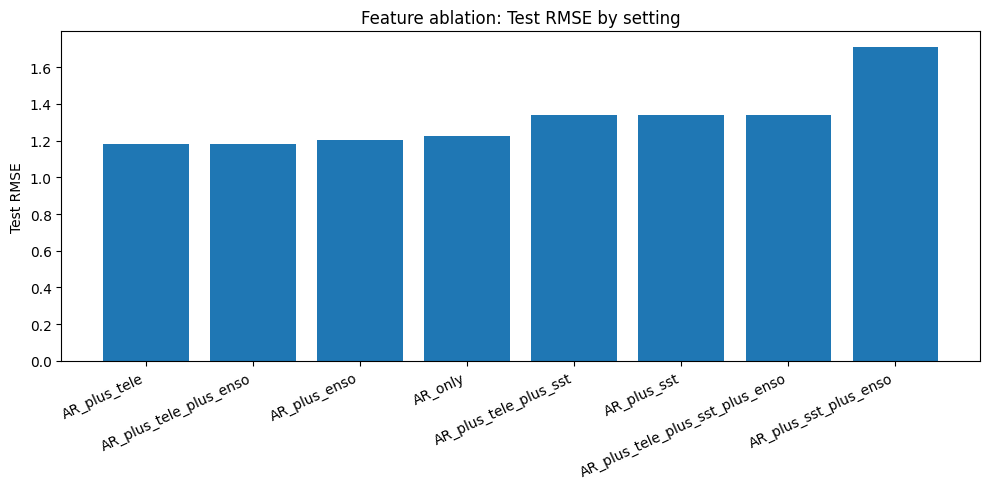

In [11]:
plot_df = ablation_df.sort_values("test_rmse").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["run"], plot_df["test_rmse"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test RMSE")
plt.title("Feature ablation: Test RMSE by setting")
plt.tight_layout()
save_current_plot("02_feature_ablation_test_rmse_by_setting.png")
plt.show()

### **Plot: test MAE by ablation setting**

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/02_feature_ablation_test_mae_by_setting.png


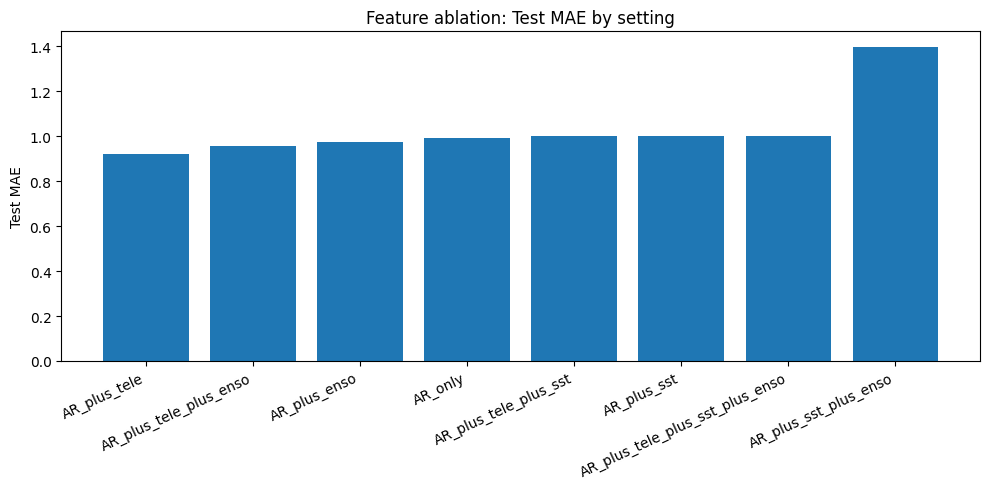

In [12]:
plot_df = ablation_df.sort_values("test_mae").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["run"], plot_df["test_mae"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test MAE")
plt.title("Feature ablation: Test MAE by setting")
plt.tight_layout()
save_current_plot("02_feature_ablation_test_mae_by_setting.png")
plt.show()

### **Compare each setting against the AR-only reference**

This comparison asks whether added climate predictors improve on autoregressive persistence alone. Negative deltas indicate lower error than the AR-only run.

Ablation delta table relative to AR_only


,run,val_best_model,test_rmse,test_mae,dRMSE_vs_AR_only,dMAE_vs_AR_only
0,AR_plus_tele,NHiTS,1.178862,0.920623,-0.048027,-0.070825
1,AR_plus_tele_plus_enso,NHiTS,1.179506,0.956040,-0.047383,-0.035407
2,AR_plus_enso,NHiTS,1.202017,0.973281,-0.024872,-0.018166
3,AR_only,Ridge,1.226889,0.991447,0.000000,0.000000
4,AR_plus_sst,Baseline,1.337108,1.001100,0.110219,0.009653
5,AR_plus_tele_plus_sst,Baseline,1.337108,1.001100,0.110219,0.009653
6,AR_plus_tele_plus_sst_plus_enso,Baseline,1.337108,1.001100,0.110219,0.009653
7,AR_plus_sst_plus_enso,NHiTS,1.709024,1.397332,0.482135,0.405885


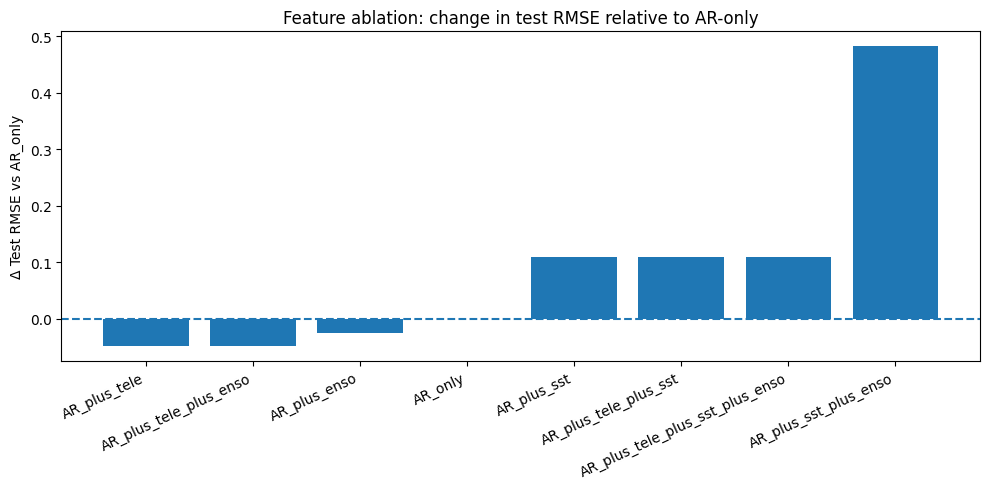

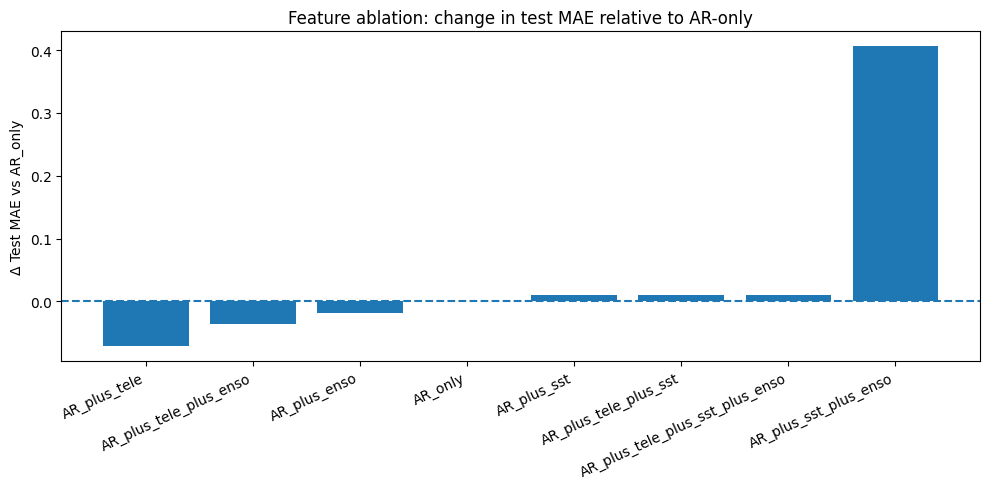

In [13]:
# Build direct ablation deltas relative to the AR-only run
ar_only_row = ablation_df.loc[ablation_df["run"] == "AR_only"].iloc[0]

ar_only_rmse = float(ar_only_row["test_rmse"])
ar_only_mae = float(ar_only_row["test_mae"])

ablation_df["dRMSE_vs_AR_only"] = ablation_df["test_rmse"] - ar_only_rmse
ablation_df["dMAE_vs_AR_only"] = ablation_df["test_mae"] - ar_only_mae

delta_view = (
    ablation_df[
        [
            "run",
            "val_best_model",
            "test_rmse",
            "test_mae",
            "dRMSE_vs_AR_only",
            "dMAE_vs_AR_only",
        ]
    ]
    .sort_values(["dRMSE_vs_AR_only", "dMAE_vs_AR_only"])
    .reset_index(drop=True)
)

print("Ablation delta table relative to AR_only")
display(delta_view)

# Plot 1: RMSE change relative to AR_only
plot_df = delta_view.sort_values("dRMSE_vs_AR_only").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["run"], plot_df["dRMSE_vs_AR_only"])
plt.axhline(0.0, linestyle="--")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Δ Test RMSE vs AR_only")
plt.title("Feature ablation: change in test RMSE relative to AR-only")
plt.tight_layout()
plt.show()

# Plot 2: MAE change relative to AR_only
plot_df = delta_view.sort_values("dMAE_vs_AR_only").reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["run"], plot_df["dMAE_vs_AR_only"])
plt.axhline(0.0, linestyle="--")
plt.xticks(rotation=25, ha="right")
plt.ylabel("Δ Test MAE vs AR_only")
plt.title("Feature ablation: change in test MAE relative to AR-only")
plt.tight_layout()
plt.show()

### **Full overall validation tables for each run**


In [14]:
for label, rr in run_objects.items():
    print(f"/n===== {label} : FULL VAL TABLE =====")
    display(rr.overall_val.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))

/n===== AR_only : FULL VAL TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,Ridge,1.075594,0.864756,-0.278317,0.145833,0.250000,0.375000
1,NHiTS,1.079984,0.842874,-0.185582,0.208333,0.322917,0.375000
2,iTransformer,1.104604,0.862929,-0.275914,0.208333,0.260417,0.322917
3,Huber,1.105530,0.875450,-0.303709,0.177083,0.229167,0.364583
4,LSTM,1.117602,0.890299,-0.338323,0.104167,0.208333,0.364583
5,PatchTST,1.123805,0.881196,-0.312420,0.166667,0.239583,0.322917
6,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
7,XGBoost,1.186165,0.946177,-0.358264,0.177083,0.250000,0.322917


/n===== AR_plus_tele : FULL VAL TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.085495,0.837888,-0.221016,0.187500,0.302083,0.427083
1,PatchTST,1.156796,0.887054,-0.338494,0.156250,0.229167,0.343750
2,iTransformer,1.169287,0.915073,-0.357997,0.166667,0.229167,0.333333
3,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
4,LSTM,1.191477,0.899953,-0.334528,0.187500,0.260417,0.395833
5,Ridge,1.213594,0.959723,-0.230427,0.187500,0.281250,0.322917
6,Huber,1.282258,1.019802,-0.255946,0.156250,0.208333,0.302083
7,XGBoost,1.294177,0.977130,-0.459651,0.208333,0.291667,0.354167


/n===== AR_plus_sst : FULL VAL TABLE =====


...

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.089362,0.840302,-0.215958,0.218750,0.312500,0.364583
1,PatchTST,1.091365,0.866231,-0.295443,0.187500,0.239583,0.354167
2,iTransformer,1.124731,0.881006,-0.336943,0.197917,0.229167,0.343750
3,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
4,LSTM,1.208767,0.950532,-0.249923,0.177083,0.218750,0.312500
5,Ridge,1.213594,0.959722,-0.230426,0.187500,0.281250,0.322917
6,XGBoost,1.265516,0.969590,-0.456505,0.187500,0.250000,0.333333
7,Huber,1.277681,1.012011,-0.237580,0.135417,0.229167,0.333333


/n===== AR_plus_sst_plus_enso : FULL VAL TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.127739,0.856505,-0.351201,0.187500,0.250000,0.395833
1,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
2,iTransformer,1.190188,0.932455,-0.269031,0.156250,0.218750,0.302083
3,XGBoost,1.199245,0.956274,-0.266994,0.166667,0.208333,0.291667
4,LSTM,1.295537,0.966728,-0.415378,0.187500,0.270833,0.385417
5,PatchTST,1.360481,1.045068,-0.447472,0.156250,0.239583,0.333333
6,Ridge,3.451229,2.767552,1.113866,0.041667,0.052083,0.104167
7,Huber,5.422960,4.445559,2.042503,0.020833,0.031250,0.031250


/n===== AR_plus_tele_plus_sst_plus_enso : FULL VAL TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,Baseline,1.179166,0.893356,-0.076121,0.208333,0.302083,0.375000
1,iTransformer,1.188961,0.909279,-0.389778,0.145833,0.229167,0.343750
2,XGBoost,1.227919,0.966079,-0.346450,0.156250,0.229167,0.250000
3,PatchTST,1.286732,1.019513,-0.298206,0.135417,0.187500,0.302083
4,NHiTS,1.322638,1.043718,-0.367749,0.135417,0.156250,0.281250
5,LSTM,1.381478,1.091322,-0.680960,0.093750,0.145833,0.197917
6,Ridge,3.292025,2.650304,1.058984,0.052083,0.062500,0.093750
7,Huber,4.709246,3.794166,1.309834,0.020833,0.072917,0.093750


### **Full overall test tables for each run**


In [15]:
for label, rr in run_objects.items():
    print(f"/n===== {label} : FULL TEST TABLE =====")
    display(rr.overall_test.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True))

/n===== AR_only : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.188397,0.950808,-0.351366,0.115789,0.231579,0.315789
1,PatchTST,1.198344,0.967490,-0.390598,0.168421,0.189474,0.284211
2,NHiTS,1.210912,0.976064,-0.296779,0.200000,0.252632,0.284211
3,Ridge,1.226889,0.991447,-0.399936,0.084211,0.189474,0.273684
4,Huber,1.234338,0.983255,-0.442662,0.115789,0.221053,0.294737
5,LSTM,1.238639,0.995489,-0.433328,0.189474,0.221053,0.273684
6,XGBoost,1.319461,1.040957,-0.348675,0.178947,0.210526,0.315789
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526


/n===== AR_plus_tele : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.178862,0.920623,-0.338202,0.200000,0.294737,0.357895
1,PatchTST,1.208003,0.969515,-0.456356,0.136842,0.189474,0.284211
2,iTransformer,1.227377,0.999558,-0.512461,0.115789,0.157895,0.263158
3,Ridge,1.234560,0.967170,-0.463849,0.168421,0.252632,0.336842
4,LSTM,1.240158,1.010427,-0.506386,0.105263,0.157895,0.263158
5,Huber,1.249319,0.972750,-0.512744,0.189474,0.284211,0.347368
6,XGBoost,1.256983,0.994715,-0.535557,0.189474,0.263158,0.336842
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526


/n===== AR_plus_sst : FULL TEST TABLE =====


...

,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,NHiTS,1.179506,0.956040,-0.393226,0.147368,0.210526,0.305263
1,PatchTST,1.180216,0.939702,-0.358108,0.147368,0.210526,0.368421
2,iTransformer,1.196984,0.956237,-0.404465,0.136842,0.200000,0.357895
3,LSTM,1.199201,0.946645,-0.449931,0.157895,0.210526,0.336842
4,Ridge,1.234560,0.967169,-0.463849,0.168421,0.252632,0.336842
5,Huber,1.248222,0.968403,-0.505928,0.210526,0.263158,0.368421
6,XGBoost,1.275036,1.018314,-0.581218,0.210526,0.231579,0.326316
7,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526


/n===== AR_plus_sst_plus_enso : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.279351,1.011597,-0.336506,0.126316,0.210526,0.326316
1,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
2,XGBoost,1.399154,1.120686,-0.515179,0.189474,0.242105,0.326316
3,PatchTST,1.478925,1.227091,-0.904776,0.073684,0.115789,0.157895
4,LSTM,1.487879,1.245073,-0.813722,0.073684,0.115789,0.210526
5,NHiTS,1.709024,1.397332,-1.129632,0.136842,0.178947,0.200000
6,Ridge,3.259816,2.614903,1.781491,0.052632,0.115789,0.147368
7,Huber,4.625381,3.776623,2.638502,0.031579,0.031579,0.042105


/n===== AR_plus_tele_plus_sst_plus_enso : FULL TEST TABLE =====


,Model,RMSE,MAE,Bias,Acc@0.25,Acc@0.35,Acc@0.50
0,iTransformer,1.262571,1.029460,-0.560807,0.094737,0.147368,0.252632
1,PatchTST,1.321057,1.090946,-0.497183,0.094737,0.147368,0.210526
2,NHiTS,1.322534,1.076753,-0.581820,0.126316,0.168421,0.305263
3,Baseline,1.337108,1.001100,-0.016177,0.210526,0.305263,0.410526
4,XGBoost,1.351173,1.064186,-0.616252,0.210526,0.242105,0.336842
5,LSTM,1.490535,1.244283,-0.923286,0.115789,0.147368,0.231579
6,Ridge,3.217617,2.603211,1.715126,0.073684,0.094737,0.105263
7,Huber,3.852630,3.056878,1.242799,0.084211,0.094737,0.136842


### **Save leaderboard to CSV**

In [16]:
out_dir = PROJECT_ROOT / "notebooks_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

leaderboard_path = out_dir / "02_feature_ablation_leaderboard.csv"
ablation_leaderboard.to_csv(leaderboard_path, index=False)

print("Saved:", project_relative(leaderboard_path))

Saved: notebooks_outputs/02_feature_ablation_leaderboard.csv


---

# **Part 4: Conclusion**

### **Overall Takeaways**

* Notebook 02 shows that the retained model set can benefit from adding climate features beyond autoregressive history, but the gains depend on whether the decision is based on validation or held-out test performance.
* The best held-out test result is AR_plus_tele, with NHiTS selected on validation and test RMSE near 1.179 and MAE near 0.921. AR_plus_tele_plus_enso is nearly tied on RMSE near 1.180, but has weaker MAE.
* The best validation result is AR_plus_enso, with validation RMSE near 1.062. Its held-out test RMSE is weaker, near 1.202, but it gives the cleanest validation-supported feature scope for the later controlled experiments.
* SST-based feature sets do not carry forward. In this run, settings that include SST either fall back to the baseline-level result or perform much worse, especially AR_plus_sst_plus_enso on test.
* The downstream pipeline carries forward a compact AR_plus_enso setup with SST and teleconnections off. This choice prioritizes a focused, validation-selected experimental path for recency weighting, temporal lag tuning, model hypertuning, residual climatology design, and horizon transfer.

---